In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras


# day 3
## page 311 

In [86]:
from keras.applications.vgg16 import VGG16, preprocess_input

basic_model = VGG16(weights='imagenet', include_top=False)
basic_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:

# weight hole , 학습된 가중치가 변경되지 않도록 한다. 
basic_model.trainable = False


model = keras.Sequential()
model.add(keras.Input(shape=(180,180,3)))
model.add(basic_model)

# 응용모델
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(256, activation='relu')) # 한번 더 요약을 위해 계층 추가 
model.add(keras.layers.Dropout(0.5)) # 사용이유 : 
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.summary()


# model compile

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)





Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [88]:
# 모델 보호를 위해 함수화 시킨다. 
def get_model():    
 
    model = keras.Sequential()
    model.add(keras.Input(shape=(180,180,3)))
    model.add(basic_model)

    # 응용모델
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(256, activation='relu')) # 한번 더 요약을 위해 계층 추가 
    model.add(keras.layers.Dropout(0.5)) # 사용이유 : 
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    return model
    
    


# 모델 보호를 위해 함수화 시킨다. 
def get_model_into_basic_model(basic_model):    

    model = keras.Sequential()
    model.add(keras.Input(shape=(180,180,3)))
    model.add(basic_model)

    # 응용모델
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(256, activation='relu')) # 한번 더 요약을 위해 계층 추가 
    model.add(keras.layers.Dropout(0.5)) # 사용이유 : 
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    return model

model.summary()


# model compile

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)
     





Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [83]:
# %load catdog.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image as Image
import torch

class CatDogDataset:
    def __init__(self, 폴더, transform=None):
        self.폴더 = Path(폴더)
        self.파일들 = list(self.폴더.glob('**/*.jpg'))
        self.labels = {'cat': 0, 'dog': 1}
        self.transform = transform
    
    def __len__(self):
        return len(self.파일들)
    
    def __getitem__(self, 색인):
        파일 = self.파일들[색인]
        target = self.labels['cat' if 'cat' in 파일.stem else 'dog']
        with Image.open(파일) as img:
            sample = img.copy()
        if self.transform:
            sample = self.transform(sample)
        return sample, target
    

def get_datasets(폴더, transform=None):
    print('# 데이터셋')
    datasets = {}
    for 하위폴더 in Path(폴더).iterdir():
        split = 하위폴더.stem
        datasets[split] = CatDogDataset(하위폴더, transform=transform)
        print(f'{split:<10}: {len(datasets[split]):,} samples')
    return datasets

def get_dataloaders(datasets, **설정):
    print('# 데이터로더')
    dataloaders = {}
    for split in datasets.keys():
        dataloaders[split] = torch.utils.data.DataLoader(
            datasets[split], shuffle=(split=='train'),
            **설정
        )
        print(f'{split:<10}: {len(dataloaders[split]):,} batches')
    return dataloaders

def get_train_results(history, plot=True):
    train_results = pd.DataFrame(history.history)
    if plot:
        plt.figure(figsize=(10, 4))
        왼쪽 = plt.subplot(1, 2, 1) # 1행 2열의 1번째 위치
        train_results.plot(y=['loss', 'val_loss'], ax=왼쪽)
        오른쪽 = plt.subplot(1, 2, 2) # 1행 2열의 2번째 위치
        train_results.plot(y=['accuracy', 'val_accuracy'], ax=오른쪽)
        plt.tight_layout()
        plt.show()
    return train_results

def evaluate_model(model, dataloader):
    results = model.evaluate(dataloader, return_dict=True)
    return pd.Series(results)

In [135]:
from pathlib import Path
import torchvision.transforms as transform
from keras.applications.vgg16 import preprocess_input


# train
%run catdog_me.py


folder = Path('/workspace/cats_dogs_small')

# preprocessing
preprocessing = transform.Compose([
    transform.Resize((180,180)),
    transform.ToTensor(),
    # Channel first -> Last
    # C H W -> H W C
    transform.Lambda(lambda x: x.permute(1,2,0)),

    # Vgg16 preprocessing expactation value : [0,1] -> [0,255]
    transform.Lambda(lambda sample: sample * 255),
    # vgg16 preprocessing RGB - BGR , delete mean value, scaling
    transform.Lambda(lambda sample: preprocess_input(sample.numpy())),
    # numpy -> tensor
    transform.Lambda(lambda sample: torch.from_numpy(sample.copy())),
])


#datasets = {}

#for sub in folder.iterdir():
#    print(sub)
#    split = sub.stem
#    datasets[split] = CatDogDataset(sub)
#    print(f'{split:<10}: {len(datasets[split]):,}')


datasets = get_datasets(folder, transform=preprocessing)
dataloaders = get_dataloaders(datasets, batch_size=32, num_workers=4, pin_memory=True)

for X_batch, y_batch in dataloaders['train']:
    print(X_batch.shape, y_batch.shape)
    break



test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
test      : 63 batches
train     : 63 batches
validation: 32 batches
torch.Size([32, 180, 180, 3]) torch.Size([32])


In [90]:
sample, label = datasets['train'][0]
print(type(sample), sample.shape)
print(sample.min(), sample.max())

<class 'torch.Tensor'> torch.Size([180, 180, 3])
tensor(-121.6800) tensor(131.3200)


In [91]:

basic_model = VGG16(weights='imagenet', include_top=False)
basic_model.trainable = False

model = get_model_into_basic_model(basic_model)

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)
history = model.fit(
    dataloaders['train'], validation_data=dataloaders['validation'],
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint('catdog.keras', save_best_only=True)
    ]
)




Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.8047 - loss: 2.8269 - val_accuracy: 0.9600 - val_loss: 0.5653
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.9289 - loss: 1.0499 - val_accuracy: 0.9580 - val_loss: 0.5775
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - accuracy: 0.9486 - loss: 0.7421 - val_accuracy: 0.9610 - val_loss: 0.5704
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.9649 - loss: 0.5113 - val_accuracy: 0.9360 - val_loss: 0.9433
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.9525 - loss: 0.7044 - val_accuracy: 0.9670 - val_loss: 0.4933
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.9666 - loss: 0.5171 - val_accuracy: 0.9700 - val_loss: 0.4294
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9666 - loss: 0.5162 - val_accuracy: 0.9640 - val_loss: 0.5421
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9663 - loss: 0.5075 - val_accu

In [92]:
from catdog import get_train_results, evaluate_model


model = keras.models.load_model('catdog.keras')
evaluate_model(model, dataloaders['train'])




63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9825 - loss: 0.2520
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9825 - loss: 0.2523

accuracy    0.985000
loss        0.228883
dtype: float64

활성화 분석

In [9]:
basic_model.layers

[<InputLayer name=input_layer_2, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

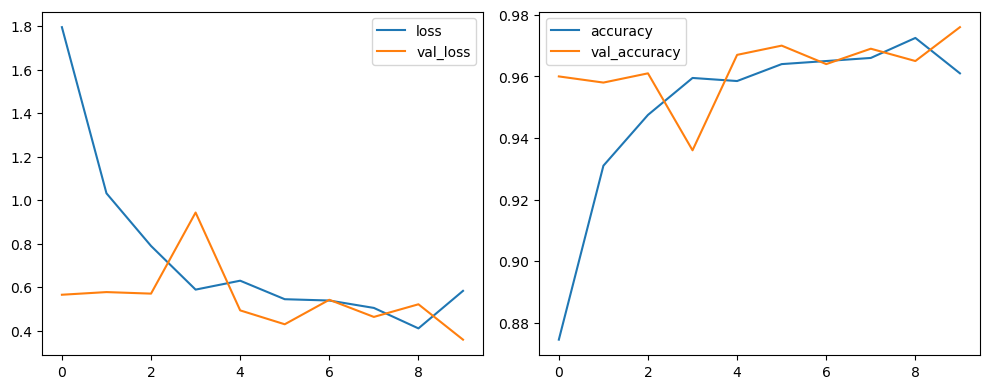

,accuracy,loss,val_accuracy,val_loss
0,0.874,1.796,0.960,0.565
1,0.931,1.032,0.958,0.577
2,0.947,0.790,0.961,0.570
3,0.960,0.589,0.936,0.943
4,0.959,0.630,0.967,0.493
5,0.964,0.545,0.970,0.429
6,0.965,0.539,0.964,0.542
7,0.966,0.505,0.969,0.463
8,0.973,0.411,0.965,0.521
9,0.961,0.583,0.976,0.359


In [93]:
train_results = get_train_results(history)
train_results.round(3)

## 활성화 분석 

In [94]:

basic_model = VGG16(weights='imagenet', include_top=False, input_shape=(180, 180, 3))

activate_model = keras.Model(
    inputs=basic_model.input,
    outputs=[
        basic_model.get_layer('block1_pool').output,
        basic_model.get_layer('block2_pool').output,
        basic_model.get_layer('block3_pool').output,
        basic_model.get_layer('block4_pool').output,
        basic_model.get_layer('block5_pool').output,
    
    ]
)
activate_model.summary()

Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
from PIL import Image

with Image.open('/workspace/data/mozzi.png') as img:
    sample = img.convert('RGB')
sample = preprocessing(sample)
print(sample.shape)


# batch demansion adding -> H W C : B H W C
outputs = activate_model.predict(sample.unsqueeze(0))

#outputs = outputs.squeeze(0)
print(type(outputs), len(outputs))

def output_image(output, layout, figsize=(10,10)):
    images, area = plt.subplots(*layout, figsize=figsize)
    for i, graph in enumerate(area.flat):
        graph.imshow( output[:, :, i], cmap='gray')
        graph.axis('off')
    return images


#output = outputs[1].squeeze(0)
#print(output.shape)
#images = output_image(output, layout=(8, 8 * 2), figsize=(20,10))

#plt.savefig('activation_block2.png')
#plt.close()
#plt.show()


for i, output in enumerate(outputs):
    output = output.squeeze(0) # batch demansion delete
    print(output.shape)
    images  = output_image(
        output, 
        # 열 고정 행 계산
        layout=( output.shape[-1] // 8, 8 ),
        # 출력의 채널 수에 따라 그림 크기 조정
        # 가로 고정 세로 채널 수에 따라 비례 조정 
        figsize=( 10, 10 * output.shape[-1]//64))
    plt.savefig(f'activation_block{i+1}.png')
    plt.close()


# image 
#images, area = plt.subplots(8,8, figsize=(10,10))
#for i, graph in enumerate(area.flat):
#    graph.imshow( outputs[:, :, i], cmap='gray')
#    graph.axis('off')

#plt.tight_layout()
#plt.show()



#print(outputs)

#plt.tight_layout()
#plt.show()



torch.Size([180, 180, 3])
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
<class 'list'> 5
(90, 90, 64)
(45, 45, 128)
(22, 22, 256)
(11, 11, 512)
(5, 5, 512)


## text data 

In [96]:
from pathlib import Path

folder = Path('/workspace/koen')
assert folder.is_dir(), f'folder {folder}'

files = list(folder.glob('**/*.csv'))

datasets = {}

for file in files:
    print(file)
    split = file.stem
    datasets[split] = pd.read_csv(file)
    print(f'{split:<10}:{len(datasets[split]):,}')





/workspace/koen/test.csv
test      :104,165
/workspace/koen/train.csv
train     :833,321
/workspace/koen/validation.csv
validation:104,165


In [97]:
datasets['train'].sample(5)

,ko,en,source
179157,생활양식의 변화로 인하여 문창호지나 장판지를 대신하는 건축소재가 등장하게 되었다.,"Due to the change in life style, architectural...",125
516855,홍수범람의 시간별 자료는 ASCII 데이터로 추출된 자료를 활용하였다.,Data extracted as ASCII data were used for the...,124
473242,만취 상태 운전자가 횡단보도에 서 있던 윤창호씨를 치어 숨지게 하는 등 음주 관련 ...,"Drinking-related traffic accidents, violence, ...",126
744830,프로세서(130)는 산출된 복수의 미분계수의 증감률 중 일부가 기설정된 기준 증감률...,When some of the calculated increase/decrease ...,71266
551478,19세 미만 자녀는 미성년자 조회를 신청하면 동의 없이 조회가 가능하다.,Children under the age of 19 can search withou...,125


In [98]:
sort_code = datasets['train']['source']

sort_code_cnt = sort_code.value_counts()

pd.DataFrame({'도수':sort_code_cnt, '비율': sort_code_cnt /sum(sort_code_cnt)}).round(3)



,도수,비율
source,,
71265,198471,0.238
126,128104,0.154
125,108894,0.131
124,108014,0.130
111,107520,0.129
71266,106518,0.128
71382,46831,0.056
563,28969,0.035


In [99]:
분류코드 = datasets['train']['source']
분류코드도수 = 분류코드.value_counts()
pd.DataFrame({'도수': 분류코드도수, '비율': 분류코드도수 / sum(분류코드도수)}).round(3)

,도수,비율
source,,
71265,198471,0.238
126,128104,0.154
125,108894,0.131
124,108014,0.130
111,107520,0.129
71266,106518,0.128
71382,46831,0.056
563,28969,0.035


In [100]:
분류필터 = datasets['train']['source'] == 71265 # 구어체 텍스트
datasets['train'][분류필터].sample(5)

,ko,en,source
435984,당사는 이미 전 세계 30개 이상의 국가와 비즈니스를 수행했습니다.,We have already done business with more than 3...,71265
519025,우리는 고객의 주머니가 가능한 한 저렴하지 않도록 할인을 제공 할 것입니다.,We will offer discounts just so the pockets of...,71265
140229,이번에 방문하시는 일정이 당겨지셨던데 무슨 일이 있으신가요?,Your visit schedule has been pushed back. Is t...,71265
482437,123 FFF1 모델입니다.,It's a 123 FFF1 model.,71265
148768,"안녕하세요, 귀하의 공장에 있는 섬유 장비의 유형을 알려주실 수 있습니까?","Hello, can you tell me the type of textile equ...",71265


## tokenize

1. each sentence one by one

In [58]:
with open('한국어문장.txt', 'w') as 파일:
    for 색인, 행 in datasets['train'].iterrows():
        파일.write(행['ko'] + '\n')



In [59]:
# 결과 확인
with open('한국어문장.txt', 'r') as 파일:
    for _ in range(5):
        print(파일.readline().strip())

지방세법 개정안에 따른 종합부동산세는 부과징수권자의 경우를 제외하고는 대부분 종전 종 합부동산세와 동일하다.
실신 당시 5초 정도 의식소실이 있었고 바로 의식은 회복되으며 신경학적 이상증상은 나타나지 않았다고 한다.
문 대통령의 10월 방일이 성사될 경우 한·일 양국은 일본군 위안부 합의 이행 문제와 독도 문제 등으로 삐걱대는 양국 관계를 개선할 계기를 만들 것이라고 신문은 전망했다.
인덱스 펀드에 대한 투자에서는 장기적인 관점에서 수익을 얻을 수 있습니다.
돌봐야 하는 비용도 있지.


In [102]:
import sentencepiece as spm

voca_cnt = 30000

sentence_cnt = 100000
spm.SentencePieceTrainer.train(
    input='한국어문장.txt',
    # random 10000 sentence train
    input_sentence_size=sentence_cnt,
    model_prefix='spm',
    vocab_size=voca_cnt,
    shuffle_input_sentence=True,
)


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: 한국어문장.txt
  input_format: 
  model_prefix: spm
  model_type: UNIGRAM
  vocab_size: 30000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 100000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differe

In [103]:
tokenizer = spm.SentencePieceProcessor(model_file='spm.model')
example = '한국어 문장을 형태소 단위로 분리합니다.'
morpheme = tokenizer.encode(example, out_type=str)
morpheme_cnt = tokenizer.encode(example, out_type=int)

display(
pd.DataFrame({
    'morpheme': morpheme,
    'cnt' : morpheme_cnt
}).T)

restoration = tokenizer.decode(morpheme_cnt)
print(restoration)


,0,1,2,3,4,5,6,7,8
morpheme,▁한국어,▁문장,을,▁형태,소,▁단위로,▁분리,합니다,.
cnt,4804,4984,5,1301,391,5997,959,121,3


한국어 문장을 형태소 단위로 분리합니다.


In [104]:
# 정수ID
pd.DataFrame({
    '토큰': [tokenizer.id_to_piece(i) for i in range(15)]
}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
토큰,<unk>,<s>,</s>,.,의,을,",",를,는,▁,에,가,이,은,▁수


In [65]:
with open('english_sentence.txt', 'w') as file:
    for index, row in datasets['train'].iterrows():
        file.write(row['en'] + '\n')



In [66]:
# 결과 확인
with open('english_sentence.txt', 'r') as file:
    for _ in range(5):
        print(file.readline().strip())

Comprehensive real estate tax according to the amendment to the local tax law is mostly the same as the previous comprehensive real estate tax, except for the tax collector.
At the time of fainting, there was a loss of consciousness for about 5 seconds, and consciousness was immediately restored and no neurological symptoms were observed.
If President Moon visits Japan in October, the newspaper predicted that both Korea and Japan would create an opportunity to improve the squeaky relationship between the of the agreement on the comfort women problem of the Japanese army and Dokdo.
Investment in index funds provides profitability in the long run.
I also have expenses to take care of.


In [67]:

examples = [
    '한국어 문장을 형태소 단위로 분리합니다.',
    'tokenize an English sentence info subwords'
]

tokenizer = spm.SentencePieceProcessor(model_file='spm.model')

for example in examples:

    morpheme = tokenizer.encode(example, out_type=str)
    morpheme_cnt = tokenizer.encode(example, out_type=int)

    display(
    pd.DataFrame({
        'morpheme': morpheme,
        'cnt' : morpheme_cnt
    }).T)

    restoration = tokenizer.decode(morpheme_cnt)
    print(restoration)


,0,1,2,3,4,5,6,7,8
morpheme,▁한국어,▁문장,을,▁형태,소,▁단위로,▁분리,합니다,.
cnt,8267,10154,12,1217,466,12409,2164,236,3


한국어 문장을 형태소 단위로 분리합니다.


,0,1,2,3,4,5,6,7,8,9,10
morpheme,▁token,ize,▁an,▁English,▁sentence,▁info,▁sub,w,or,d,s
cnt,17368,4443,39,3647,4370,27952,1513,1915,283,93,13


tokenize an English sentence info subwords


In [77]:
# 정수ID
pd.DataFrame({
    '토큰': [tokenizer.id_to_piece(i) for i in range(15)]
}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
토큰,<unk>,<s>,</s>,.,▁the,",",▁of,▁,의,▁a,▁and,▁to,을,s,▁in


In [68]:
# special token 
tokenizer.decode(list(range(10)))

for i in range(10):
    tokenizer.id_to_piece(0)

# integer Id
pd.DataFrame({
    'token': [tokenizer.id_to_piece(i) for i in range(20)]
}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
token,<unk>,<s>,</s>,.,▁the,",",▁of,▁,의,▁a,▁and,▁to,을,s,▁in,를,▁is,는,에,-


In [78]:
%run text_me.py

preprocessing = lambda text: tokenizer.encode(text, out_type=int)

datasets = {}

for filepath in files:
    frame = pd.read_csv(filepath)
    split = filepath.stem
    datasets[split] = TextDataset(frame['ko'], transform=preprocessing)


sample = datasets['train'][0]
print(sample)



[26555, 12782, 18, 385, 29451, 17, 3715, 6439, 246, 713, 2148, 162, 15, 6928, 17, 1496, 13620, 2778, 3580, 29019, 361, 43, 16759, 3]


## text sorting 

In [106]:
class TextDataset:
    def __init__(self, texts, labels=None, transform=None):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, 색인):
        sample = self.texts[색인]
        if self.transform:
            sample = self.transform(sample)
            
        if self.labels is not None:
            label = self.labels[색인]
            return sample, label
        return sample

전처리 = lambda text: tokenizer.encode(text, out_type=int)

datasets = {}
for 파일경로 in files:
    frame = pd.read_csv(파일경로)
    split = 파일경로.stem
    datasets[split] = TextDataset(frame['ko'], transform=전처리)

sample = datasets['train'][0]
print(sample)

[18283, 5446, 10, 144, 2818, 14479, 211, 8, 1943, 16944, 8342, 4, 63, 7, 9080, 694, 7544, 1463, 2729, 14479, 211, 19, 8777, 3]


In [70]:
preprocessing = lambda text: tokenizer.encode(text, out_type=int)

datasets = {}

for split, sample in [('train',1000), ('validation',1000), ('test',1000)]:
    frame = pd.read_csv( folder / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거 

    # 10000 개 sample
    morpheme = frame[frame['source'] == 71265].sample(sample, random_state=0)
    patent = frame[frame['source'] == 563].sample(sample, random_state=0)

    samples = pd.concat([morpheme, patent], ignore_index=True)

    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=preprocessing
    )
    print(f'{split:<10}: {len(datasets[split]):,}')

    print(samples['source'].value_counts().to_string())
    # 구어체와 특허 의 문장 특징을 어떻게 찾아낼까?
    #train_sample = pd.concat([morpheme, patent], ignore_index=True)
    #train_sample.drop(columns=['en'], inplace=True)
    #train_sample.sample(5, random_state=0)



train     : 2,000
source
71265    1000
563      1000
validation: 2,000
source
71265    1000
563      1000
test      : 2,000
source
71265    1000
563      1000


In [112]:
# develop

def preprocessing(text, max_len):
    int_sequence = tokenizer.encode(text, out_type=int)
    return int_sequence[:max_len]

#preprocessing = lambda text: tokenizer.encode(text, out_type=int)

%run text_me.py
datasets = {}

for split, sample_cnt in [('train',10000), ('validation',1000), ('test',1000)]:
    frame = pd.read_csv( folder / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거 

    # 10000 개 sample
    morpheme = frame[frame['source'] == 71265].sample(sample_cnt, random_state=0)
    patent = frame[frame['source'] == 563].sample(sample_cnt, random_state=0)

    samples = pd.concat([morpheme, patent], ignore_index=True)

    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=lambda text: preprocessing(text, max_len=300)
    )
    print(f'{split:<10}: {len(datasets[split]):,}')

    print(samples['source'].value_counts().to_string())
    # 구어체와 특허 의 문장 특징을 어떻게 찾아낼까?
    #train_sample = pd.concat([morpheme, patent], ignore_index=True)
    #train_sample.drop(columns=['en'], inplace=True)
    #train_sample.sample(5, random_state=0)



train     : 20,000
source
71265    10000
563      10000
validation: 2,000
source
71265    1000
563      1000
test      : 2,000
source
71265    1000
563      1000


In [134]:
def 전처리(text, 최대길이):
    정수시퀀스 = tokenizer.encode(text, out_type=int)    
    return 정수시퀀스[:최대길이]

datasets = {}
for split, 샘플수 in [('train', 10000), ('validation', 1000), ('test', 1000)]:
    frame = pd.read_csv(folder / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거
    # 각 클래스에서 샘플링
    구어체 = frame[frame['source'] == 71265].sample(샘플수, random_state=0)
    특허 = frame[frame['source'] == 563].sample(샘플수, random_state=0)

    samples = pd.concat([구어체, 특허], ignore_index=True)
    print(f'split : {split}')
    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        # 텍스트 분류를 위해 클래스 레이블도 함께 제공해야 합니다.
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=lambda text: 전처리(text, 최대길이=300)
    )
    print(f'{split:<10}: {len(datasets[split]):,}')
    # 유형 도수 확인
    print(samples['source'].value_counts().to_string())

split : train
train     : 20,000
source
71265    10000
563      10000
split : validation
validation: 2,000
source
71265    1000
563      1000
split : test
test      : 2,000
source
71265    1000
563      1000


In [133]:
sample, label = datasets['train'][10001]
print(f'label: {label}\nsample: {sample}')
print('복원된 텍스트:', tokenizer.decode(sample))

label: 1
sample: [277, 782, 5, 632, 3620, 361, 86, 55, 319, 6, 176, 6, 20, 717, 5167, 15440, 3, 527, 713, 623, 5, 8010, 30, 301, 50, 1436, 17, 301, 4, 515, 5, 3707, 148, 7, 168, 3, 515, 13, 3470, 80, 343, 88, 3750, 12719, 10, 39, 9838, 688, 60, 3]
복원된 텍스트: 새로운 특징을 네트워크 서비스에 추가하기 위한 방법, 시스템, 및 컴퓨터 프로그램이 제시된다. 방법은 관심 대상을 묘사하는 이미지 또는 그러한 이미지의 선택을 수신하는 단계를 포함한다. 선택은 후속하여 디스플레이되는 아이템 이미지들에 대한 앵커 역할을 한다.


In [114]:
doc_len = [len(sample) for sample, _ in datasets['train']]
pd.Series(doc_len).describe().astype(int)


count    20000
mean        68
std         68
min          2
25%         11
50%         27
75%        121
max        300
dtype: int64

In [115]:

최대길이 = 20
정규화된_샘플 = []
for i in range(3):
    sample, _ = datasets['train'][i]
    정규화된_샘플.append(sequence_padding(sample, 최대길이))

pd.DataFrame(정규화된_샘플)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,16425,116,1392,2585,10,638,17715,34,4211,44,0,0,0,0,0,0,0,0,0,0
1,6870,37,98,400,13,9555,100,101,6459,3,0,0,0,0,0,0,0,0,0,0
2,23259,116,283,943,1895,42,4687,25,14,56,3,0,0,0,0,0,0,0,0,0


In [ ]:
%run text_me.py

# 모든 batch가 같은 길이 일수 없어도 된다. 
sample_batch = [datasets['train'][i] for i in range(3)]

Xs, ys = combine_batch(sample_batch)
print(Xs.shape, ys.shape)


#sample_batch = [datasets['train'][i] for i in range(5,8)]
#Xs, ys = combine_batch()

torch.Size([3, 17]) torch.Size([3])


In [122]:
def 시퀀스패딩(sample, 최대길이, 패딩값=0):
    assert len(sample) > 0, '샘플이 비어 있습니다.'
    sample = sample[:최대길이]
    return sample + [패딩값] * (최대길이 - len(sample))

최대길이 = 20
정규화된_샘플 = []
for i in range(3):
    sample, _ = datasets['train'][i]
    정규화된_샘플.append(시퀀스패딩(sample, 최대길이))

pd.DataFrame(정규화된_샘플)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,16425,116,1392,2585,10,638,17715,34,4211,44,0,0,0,0,0,0,0,0,0,0
1,6870,37,98,400,13,9555,100,101,6459,3,0,0,0,0,0,0,0,0,0,0
2,23259,116,283,943,1895,42,4687,25,14,56,3,0,0,0,0,0,0,0,0,0


- 베체병합을 통해서 loader를 잘만드는것 

In [132]:
def 배치병합(batch):
    samples, labels = zip(*batch)
    문서길이 = [len(sample) for sample in samples]
    최대길이 = max(문서길이) # 배치 내에서 가장 긴 샘플의 길이를 최대길이로 설정
    정규화된_샘플 = [시퀀스패딩(sample, 최대길이) for sample in samples]
    return np.array(정규화된_샘플), np.array(labels)

# 첫 번째 배치
sample_batch = [datasets['train'][i] for i in range(3)]
Xs, ys = 배치병합(sample_batch)
print(Xs.shape, ys.shape)
# 다른 배치
sample_batch = [datasets['train'][i] for i in range(5, 8)]
Xs, ys = 배치병합(sample_batch)
print(Xs.shape, ys.shape)

(3, 11) (3,)
(3, 22) (3,)


In [130]:
dataloaders = {}
split = 'train'
dataloaders[split] = torch.utils.data.DataLoader(
    datasets[split], shuffle=(split=='train'),
    batch_size=32, num_workers=2, collate_fn=배치병합
)
batch_sequence_len =[]
for X_batch, y_batch in dataloaders['train']:
    #print(X_batch.shape, y_batch.shape)
    batch_sequence_len.append(X_batch.shape[1])


pd.Series(batch_sequence_len).describe().astype(int)

count    625
mean     230
std       41
min      129
25%      198
50%      223
75%      259
max      300
dtype: int64

In [ ]:
import keras
from keras import layers

keras.backend.clear_session()

sentence_cnt = tokenizer.get_piece_size()

print(f'sentence_cnt : {sentence_cnt}')

model = keras.Sequential([
    # 가변길이 
    layers.Input(shape=(None,)),
    
    # TODO hidden layer
    layers.Embedding(input_dim=sentence_cnt, output_dim=64),
    layers.GlobalAveragePooling1D(),
    #layers.Dense(64, activation='relu'),
    # output
    layers.Dense(1, activation='sigmoid'),
])
model.summary()


model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)

history = model.fit(
    dataloaders['train'], validation_data=dataloaders['validation'],
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint('text_classifier.keras', save_best_only=True)
    ]
)

sentence_cnt : 30000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,065 (7.32 MB)

 Trainable params: 1,920,065 (7.32 MB)

 Non-trainable params: 0 (0.00 B)

RuntimeError: Unable to automatically build the model. Please build it yourself before calling fit/evaluate/predict. A model is 'built' when its variables have been created and its `self.built` attribute is True. Usually, calling the model on a batch of data is the right way to build it.
Exception encountered:
'Exception encountered when calling Sequential.call().

[1mInvalid input shape for input tensor([[[[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],

         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],

         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],

         ...,

         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1.

## one hot encoding

# 범주형 분류하기 위한 방식 
- 다만, 개 강아지 같은 유사도를 표현하기는 힘들다 


In [160]:
embeding_vector = model.layers[0].get_weights()[0]
print(embeding_vector.shape)

word = '사랑'
int_id = tokenizer.piece_to_id(word)
print(f'word :{word}, id : {int_id}')



embeding_word = embeding_vector[int_id]
print(f'vector : {embeding_word[:10].round(3)} ...')

(5000, 128)
word :사랑, id : 0
vector : [ 0.022  0.007 -0.012 -0.042  0.013 -0.021  0.008 -0.001 -0.047 -0.031] ...
